In [13]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()
model = ChatOpenAI()

In [3]:
class ChainInvoke(TypedDict):
    topic: str
    outline: str
    blog: str
    


In [7]:
def define_outline(state: ChainInvoke) -> ChainInvoke:
    topic = state.get("topic","AI")
    
    prompt = f'Generate a detailed outline for a blog on the topic - {topic}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state
    

def generate_blog(state : ChainInvoke) -> ChainInvoke:
    topic = state['topic']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {topic} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['blog'] = content

    return state


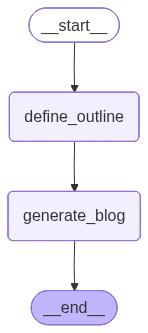

In [8]:
graph = StateGraph(ChainInvoke)

graph.add_node("define_outline",define_outline)
graph.add_node("generate_blog",generate_blog)

graph.add_edge(START,"define_outline")
graph.add_edge("define_outline","generate_blog")
graph.add_edge("generate_blog",END)

graph.compile()


In [10]:
workflow = graph.compile()

In [15]:
intial_state = {'topic': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'topic': 'Rise of AI in India', 'outline': 'I. Introduction\n    A. Definition of AI\n    B. Brief history of AI in India\n    C. Overview of the current state of AI in India\n\nII. Growth of AI in India\n    A. Adoption of AI in various industries\n        1. Healthcare\n        2. Finance\n        3. Agriculture\n        4. Education\n    B. Investment in AI technology\n        1. Government initiatives\n        2. Private sector investments\n    C. Impact of AI on the Indian economy\n\nIII. Challenges and Opportunities\n    A. Skills gap in the AI industry\n        1. Need for specialized training programs\n        2. Importance of upskilling the workforce\n    B. Ethical implications of AI in India\n        1. Data privacy concerns\n        2. Bias in AI algorithms\n    C. Opportunities for innovation and job creation\n\nIV. Future of AI in India\n    A. Potential growth areas for AI technology\n        1. Robotics\n        2. Natural language processing\n        3. Autonomous veh